
# Attention Rollout & Attention Flow
### Abnar & Zuidema (2020) — aggregating attention across layers

Raw self-attention weights from a single transformer layer are not a reliable explanation of a model's prediction, because by the time you reach a deep layer, every token's representation is already a mixture of many other tokens. This notebook covers two methods for turning **per-layer attention** into a single, more meaningful **token attribution score**:

- **Attention Rollout** — combine attention across layers via matrix multiplication.
- **Attention Flow** — combine attention across layers via a max-flow computation on a graph.

We'll apply both to a BERT model fine-tuned on the `dair-ai/emotion` dataset.

**Contents**
1. Setup
2. A tiny worked example
3. Dataset & model
4. Attention Rollout
5. Attention Flow
6. Comparing the two methods
7. Applying this to the dataset


## 1. Setup

In [ ]:
# Uncomment to install dependencies
# !pip install -q torch transformers datasets networkx matplotlib seaborn


In [12]:
import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def clean_tokens(tokens, scores):
    '''Drop [CLS]/[SEP] and renormalize, so bar charts show only content words.'''
    keep = [(t, s) for t, s in zip(tokens, scores) if t not in ("[CLS]", "[SEP]")]
    kept_tokens = [t for t, s in keep]
    kept_scores = np.array([s for t, s in keep], dtype=float)
    if kept_scores.sum() > 0:
        kept_scores = kept_scores / kept_scores.sum()
    return kept_tokens, kept_scores


def plot_attribution(tokens, scores, color, pred_label, type="Rollout"):
    tokens_r, scores_r = clean_tokens(tokens, scores)
    plt.figure(figsize=(7, 3))
    plt.bar(tokens_r, scores_r, color=color)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(f"{type} attribution")
    plt.title(f"{type} — prediction: {pred_label}")
    plt.tight_layout()
    plt.show()



**Attention Flow**: build a graph where each edge $(l,j) \to (l+1,i)$ has capacity $\hat A^{(l)}_{i,j}$, and compute the **max-flow** from each input token to `[CLS]` at the last layer. This respects capacity limits instead of just adding up paths, so it can't over-count reinforcing routes the way rollout can.



## 3. Dataset & model

We'll use `dair-ai/emotion` (6 labels: sadness, joy, love, anger, fear, surprise) and a BERT checkpoint already **fine-tuned on this task**. This matters: if we used plain, un-fine-tuned `bert-base-uncased`, its classification head would be random and the prediction meaningless — so there'd be nothing real to explain. The fine-tuned checkpoint's `[CLS]` attention is actually shaped by learning to classify emotions.


In [13]:
ds = load_dataset("dair-ai/emotion", "split")
label_names = ds["train"].features["label"].names
print("Labels:", label_names)


Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [16]:
MODEL_NAME = "/Users/narimene/Downloads/distilbert-emotion"
FALLBACK_MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, output_attentions=True)

# try:
# except Exception:
#     tokenizer = AutoTokenizer.from_pretrained(FALLBACK_MODEL_NAME)
#     model = AutoModelForSequenceClassification.from_pretrained(
#         FALLBACK_MODEL_NAME, num_labels=6, output_attentions=True
    # )

model.to(DEVICE).eval()
print(f"Layers: {model.config.num_hidden_layers}, heads: {model.config.num_attention_heads}")


def get_attentions(text, max_length=24):
    '''Returns tokens, per-layer attentions (tuple of (1, heads, seq, seq)), and logits.'''
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length).to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    attentions = tuple(a.cpu() for a in outputs.attentions)
    return tokens, attentions, outputs.logits.cpu()


Layers: 6, heads: 12


In [17]:
text = "i feel so anxious and scared about tomorrow"
tokens, attentions, logits = get_attentions(text)
pred_label = label_names[logits.argmax(-1).item()]
print("Tokens:", tokens)
print("Prediction:", pred_label)


TypeError: forward() got an unexpected keyword argument 'token_type_ids'


## 4. Attention Rollout

### Intuition

Raw attention only looks at one layer. But in a Transformer, representations are repeatedly mixed. If token A attends to token B in layer 1, and `[CLS]` attends to token A in layer 2, then information from token B can influence `[CLS]` indirectly.

Attention rollout approximates this by multiplying attention matrices across layers.

### Residual connections

Transformer layers also include residual connections. Abnar & Zuidema account for this by adding an identity matrix before normalizing:

$$
\hat{A}^{(l)} = normalize\_rows(A_l + I)
$$

Then rollout multiplies these matrices:

$$
R = \hat{A}^{(l)} \times \hat{A}^{(l-1)} \times ... \times \hat{A}^{(1)}
$$

The row for `[CLS]` in `R` estimates how much the final `[CLS]` representation is connected to each input token through the stack.


In [6]:
def compute_rollout(attentions, residual_weight=0.5):
    '''Attention Rollout (Abnar & Zuidema, 2020).
    Returns an (seq, seq) matrix; row i = attribution of every token to token i.
    '''
    seq_len = attentions[0].size(-1)
    result = torch.eye(seq_len)
    for layer_att in attentions:
        A = layer_att[0].mean(dim=0)  # average over heads
        A = (1 - residual_weight) * A + residual_weight * torch.eye(seq_len)
        A = A / A.sum(dim=-1, keepdim=True)
        result = A @ result
    return result


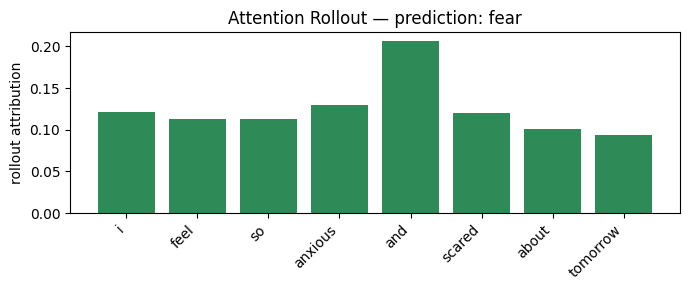

In [7]:
rollout = compute_rollout(attentions)
rollout_cls = rollout[0].numpy()  # [CLS] row = attribution for the classification decision

plot_attribution(tokens, rollout_cls, color="C0", pred_label=pred_label, type="Rollout")


## 5. Attention Flow

### Intuition

Attention rollout multiplies matrices, which sums over all possible paths. Attention flow instead treats attention as a **flow network**:

- Each token at each layer is a node.
- Edges point from a token representation at layer `l` to the source tokens at layer `l-1`.
- Edge capacities are the residual-aware attention values.
- We compute how much flow can travel from the final `[CLS]` node back to each input token.

This gives a graph-theoretic view of how information could pass through the stack.

One practical note: we use a smaller residual weight here (0.1 instead of 0.5). A high residual weight gives every token a strong "attend to yourself" edge at every layer, which — stacked across 12 BERT layers — tends to wash out real differences between tokens. A smaller residual weight keeps the max-flow scores more informative.


In [8]:
def compute_attention_flow(attentions, sink_idx=0, residual_weight=0.1):
    '''Attention Flow (Abnar & Zuidema, 2020), simplified: max-flow from each
    input token to `sink_idx` at the final layer.
    '''
    seq_len = attentions[0].size(-1)
    L = len(attentions)
    G = nx.DiGraph()
    for l, layer_att in enumerate(attentions):
        A = layer_att[0].mean(dim=0)
        A = (1 - residual_weight) * A + residual_weight * torch.eye(seq_len)
        A = A / A.sum(dim=-1, keepdim=True)
        A = A.numpy()
        for i in range(seq_len):
            for j in range(seq_len):
                w = float(A[i, j])
                if w > 1e-6:
                    G.add_edge((l, j), (l + 1, i), capacity=w)

    flows = np.zeros(seq_len)
    sink = (L, sink_idx)
    for j in range(seq_len):
        source = (0, j)
        if source == sink:
            flows[j] = 1.0
            continue
        val, _ = nx.maximum_flow(G, source, sink, flow_func=nx.algorithms.flow.edmonds_karp)
        flows[j] = val
    return flows


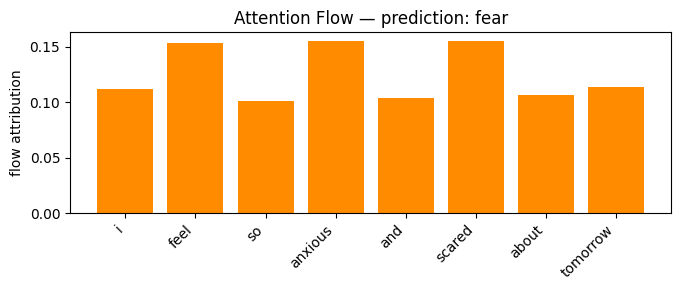

In [9]:
flow_scores = compute_attention_flow(attentions, sink_idx=0)
tokens_f, scores_f = clean_tokens(tokens, flow_scores)

plot_attribution(tokens, flow_scores, color="C1", pred_label=pred_label, type="Attention Flow")



## 6. Comparing the two methods (and raw attention)

Let's put raw last-layer attention, rollout, and flow side by side on the same sentence.


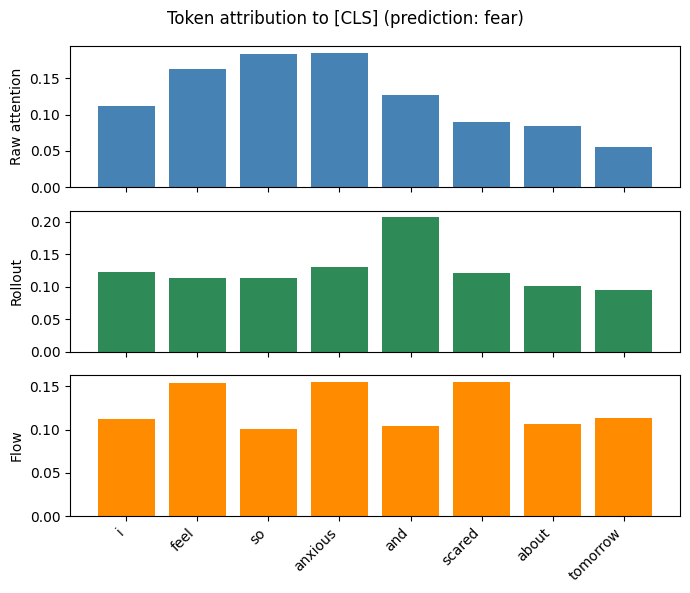

In [10]:
raw_scores = attentions[-1][0].mean(dim=0)[0].numpy()  # last-layer, [CLS] row, head-averaged

tokens_raw, raw_c = clean_tokens(tokens, raw_scores)
_, rollout_c = clean_tokens(tokens, rollout_cls)
_, flow_c = clean_tokens(tokens, flow_scores)

fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True)
for ax, scores, name, color in zip(
    axes,
    [raw_c, rollout_c, flow_c],
    ["Raw attention", "Rollout", "Flow"],
    ["steelblue", "seagreen", "darkorange"],
):
    ax.bar(tokens_raw, scores, color=color)
    ax.set_ylabel(name)
plt.xticks(rotation=45, ha="right")
plt.suptitle(f"Token attribution to [CLS] (prediction: {pred_label})")
plt.tight_layout()
plt.show()


### Interpretation

Each panel is a different, imperfect proxy for "how much did this token matter to the prediction?" — they won't fully agree, and that disagreement is itself instructive. A practical way to interpret them together:

1. **Look for convergence first.** If a token scores high across *most* panels, that's a reasonably trustworthy signal it's doing real work in the model's decision — e.g. an emotion word that's high in raw attention, rollout, *and* flow is a much stronger candidate than one that's only high in one panel.
2. **Treat the single highest bar in any one panel with caution.** Each method has known blind spots (see below), so "the top-ranked token according to rollout" is a weaker claim than "a token several methods agree is important."
3. **Disagreements are teaching moments, not errors.** If rollout puts a function word (like "and") above an obvious content word, that's worth discussing: rollout's path-multiplication can let attention hubs accumulate credit even when they aren't the semantic reason for the prediction. Flow, respecting capacity constraints, is less prone to this but tends to smooth out differences more. Raw attention only sees the last layer, so it can miss influence that happened earlier and got carried forward via the residual stream.
4. **None of the three panels is ground truth.** They're all suggestive signals for generating hypotheses about model behavior — useful for spotting patterns worth investigating further, not for declaring "this is definitely the word that caused the prediction."


### Summary 

Things worth pointing out to students:
- **Raw attention** only reflects the last layer; it ignores everything that happened earlier in the network.
- **Rollout** aggregates all layers by treating attention as additive across paths — cheap to compute, but can overstate influence when many paths reinforce each other.
- **Flow** aggregates all layers while respecting capacity limits — more principled, but more expensive, and tends to produce smoother (less peaked) scores than rollout on deep networks.

None of the three is a proof of what the model "really" used — they're all useful, imperfect signals for generating hypotheses about model behavior.



## 7. Applying this to the dataset

Rollout is cheap enough to run over several examples. Let's check the top attributed tokens for one example per emotion.


In [11]:
def top_k_rollout_tokens(text, k=5):
    toks, atts, logits = get_attentions(text)
    pred = label_names[logits.argmax(-1).item()]
    scores = compute_rollout(atts)[0].numpy()
    toks_c, scores_c = clean_tokens(toks, scores)
    order = np.argsort(-scores_c)[:k]
    return pred, [(toks_c[i], float(scores_c[i])) for i in order]

seen = set()
for ex in ds["train"]:
    lbl = label_names[ex["label"]]
    if lbl in seen:
        continue
    seen.add(lbl)
    pred, top = top_k_rollout_tokens(ex["text"])
    print(f"True: {lbl:8s} | Pred: {pred:8s} | Text: {ex['text']}")
    print("  Top tokens:", ", ".join(f"{t} ({s:.2f})" for t, s in top))
    print()
    if len(seen) == len(label_names):
        break


True: sadness  | Pred: sadness  | Text: i didnt feel humiliated
  Top tokens: humiliated (0.24), ##t (0.22), i (0.21), feel (0.19), didn (0.14)

True: anger    | Pred: anger    | Text: im grabbing a minute to post i feel greedy wrong
  Top tokens: a (0.15), to (0.13), i (0.10), wrong (0.09), feel (0.09)

True: love     | Pred: love     | Text: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
  Top tokens: the (0.08), the (0.08), property (0.06), nos (0.06), on (0.06)

True: surprise | Pred: joy      | Text: ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
  Top tokens: a (0.07), and (0.07), but (0.06), faster (0.05), asleep (0.05)

True: fear     | Pred: fear     | Text: i feel as confused about life as a teenager or as jaded as a year old man
  Top tokens: a (0.08), a (0.08), confused (0.07), i (0.07), or (0.06)

True: joy      | Pred: joy      | Text: i have been with


## Reference

Abnar, S., & Zuidema, W. (2020). *Quantifying Attention Flow in Transformers.* ACL 2020.
